In [1]:
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

DATA_DIR = Path("../../../data/CCN_synthesis")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DEPTH_TARGETS = [0, 30, 100]

# lower/eastern coast
REGION_BBOX = {
    "lat_min": 24.5,
    "lat_max": 35.0,
    "lon_min": -98.0,
    "lon_max": -75.0,
}
print(
    f"Study region: US Lower Coast"
    f"({REGION_BBOX['lat_min']}–{REGION_BBOX['lat_max']} N, "
    f"{REGION_BBOX['lon_min']}–{REGION_BBOX['lon_max']} W)"
)

N_PCA_COMPONENTS = 30
MIN_SAMPLES = 20

Using device: cuda
Study region: US Lower Coast(24.5–35.0 N, -98.0–-75.0 W)


## Loading CCN Locally

In [2]:
cores = pd.read_csv(DATA_DIR / "CCN_cores.csv", low_memory=False)
depthseries = pd.read_csv(DATA_DIR / "CCN_depthseries.csv", low_memory=False)

print(f"Cores: {cores.shape[0]:,} rows, Depthseries: {depthseries.shape[0]:,} rows")

Cores: 16,715 rows, Depthseries: 117,518 rows


In [3]:
core_locs = cores[
    ["study_id", "site_id", "core_id", "latitude", "longitude", "habitat", "salinity_class", "vegetation_class"]
].copy()

core_locs = core_locs[
    (core_locs["latitude"] >= REGION_BBOX["lat_min"])
    & (core_locs["latitude"] <= REGION_BBOX["lat_max"])
    & (core_locs["longitude"] >= REGION_BBOX["lon_min"])
    & (core_locs["longitude"] <= REGION_BBOX["lon_max"])
].copy()
print(f"Cores within bbox: {len(core_locs):,}")


def extract_carbon_at_depth(depthseries: pd.DataFrame, depth_min: int) -> pd.DataFrame:
    """Extract mean fraction_carbon for cores at a given depth_min."""
    layer = depthseries[depthseries["depth_min"] == depth_min].copy()
    layer = layer[layer["fraction_carbon"].notna()]
    agg = (
        layer.groupby(["study_id", "site_id", "core_id"]).agg(fraction_carbon=("fraction_carbon", "mean")).reset_index()
    )
    merged = agg.merge(core_locs, on=["study_id", "site_id", "core_id"])
    merged = merged.dropna(subset=["latitude", "longitude"])
    merged = merged[(merged["fraction_carbon"] > 0) & (merged["fraction_carbon"] <= 1.0)]
    return merged


# datasets for each depth
depth_datasets = {}
for d in DEPTH_TARGETS:
    df = extract_carbon_at_depth(depthseries, d)
    depth_datasets[d] = df
    print(
        f"depth_min={d:3d} cm: {len(df):,} cores | "
        f"carbon {df['fraction_carbon'].min():.4f}–{df['fraction_carbon'].max():.4f} "
        f"(mean {df['fraction_carbon'].mean():.4f})"
    )

Cores within bbox: 3,564
depth_min=  0 cm: 607 cores | carbon 0.0006–0.4711 (mean 0.1485)
depth_min= 30 cm: 162 cores | carbon 0.0036–0.4988 (mean 0.1276)
depth_min=100 cm: 19 cores | carbon 0.0253–0.3475 (mean 0.1471)


In [4]:
all_labeled = pd.concat(depth_datasets.values(), ignore_index=True)
unique_cores = all_labeled.drop_duplicates(subset=["study_id", "site_id", "core_id"])
print(f"Unique core locations to extract: {len(unique_cores):,}")

Unique core locations to extract: 621


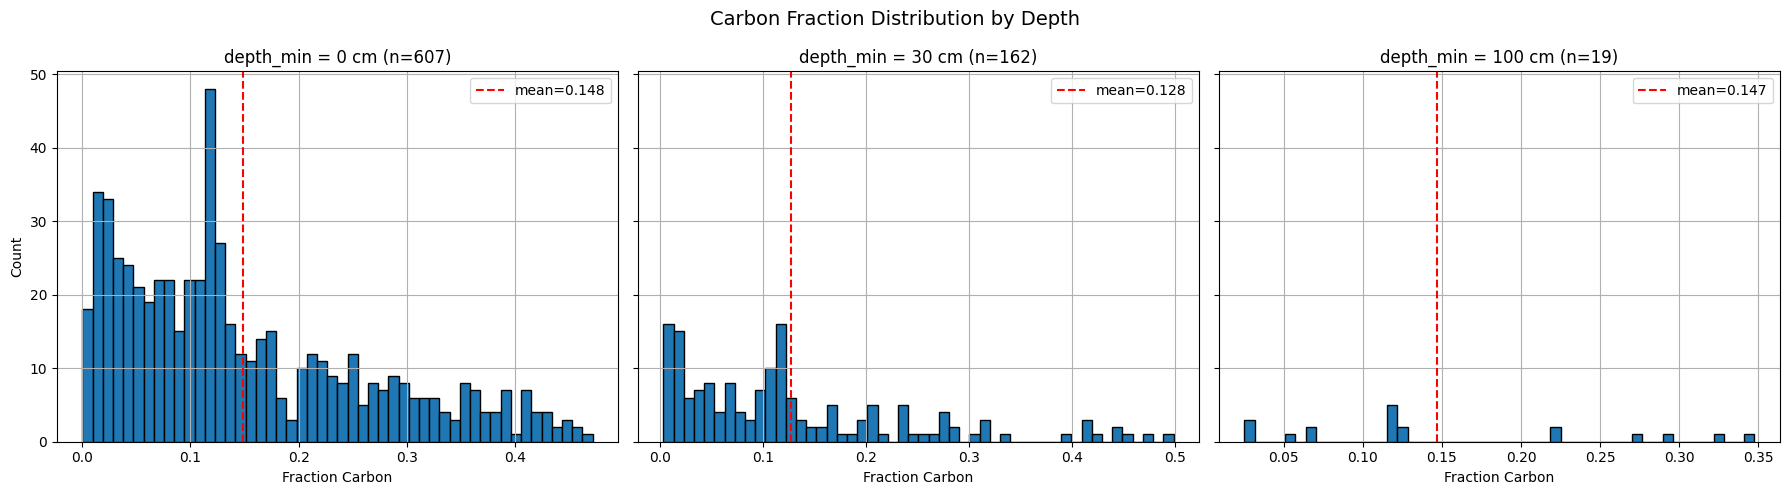

In [5]:
# carbon across depths
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, d in zip(axes, DEPTH_TARGETS):
    df = depth_datasets[d]
    df["fraction_carbon"].hist(bins=50, ax=ax, edgecolor="black")
    ax.set_xlabel("Fraction Carbon")
    ax.set_title(f"depth_min = {d} cm (n={len(df):,})")
    ax.axvline(
        df["fraction_carbon"].mean(), color="red", linestyle="--", label=f"mean={df['fraction_carbon'].mean():.3f}"
    )
    ax.legend()

axes[0].set_ylabel("Count")
fig.suptitle("Carbon Fraction Distribution by Depth", fontsize=14)
plt.tight_layout()
plt.show()

## Get EMIT data at CCN locations

In [6]:
ee.Authenticate()
GEE_PROJECT = "ee-klewtak"
ee.Initialize(project=GEE_PROJECT)

In [7]:
sites_gdf = gpd.GeoDataFrame(
    unique_cores,
    geometry=gpd.points_from_xy(unique_cores.longitude, unique_cores.latitude),
    crs="EPSG:4326",
)

ROI = ee.Geometry.Rectangle(
    [REGION_BBOX["lon_min"], REGION_BBOX["lat_min"], REGION_BBOX["lon_max"], REGION_BBOX["lat_max"]]
)


def gdf_to_ee_fc(gdf: gpd.GeoDataFrame) -> ee.FeatureCollection:
    """Convert a GeoDataFrame of points to an ee.FeatureCollection."""
    features = []
    for _, row in gdf.iterrows():
        geom = ee.Geometry.Point([row.geometry.x, row.geometry.y])
        props = {
            "core_id": str(row["core_id"]),
            "site_id": str(row["site_id"]),
            "study_id": str(row["study_id"]),
        }
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)


BATCH_SIZE = 2000
n_total = len(sites_gdf)
print(f"Total sites to extract: {n_total:,}")
print(f"Batches needed: {int(np.ceil(n_total / BATCH_SIZE))}")

Total sites to extract: 621
Batches needed: 1


In [8]:
EMIT_COLLECTION = "NASA/EMIT/L2A/RFL"
DATE_START = "2023-01-01"
DATE_END = "2025-01-01"

emit_col = ee.ImageCollection(EMIT_COLLECTION).filterDate(DATE_START, DATE_END).filterBounds(ROI)


def mask_emit_clouds(img: ee.Image) -> ee.Image:
    cloud_mask = img.select("dilated_cloud_flag").eq(0)
    return img.updateMask(cloud_mask)


emit_mosaic = emit_col.map(mask_emit_clouds).mosaic()

try:
    n_images = emit_col.size().getInfo()
    band_names = emit_mosaic.bandNames().getInfo()
    print(f"EMIT scenes: {n_images}, Bands in mosaic: {len(band_names)}")
except Exception as e:
    print(f"Info call failed (non-critical): {e}")
    print("Continuing — mosaic is defined lazily and will be computed during extraction.")

EMIT scenes: 1740, Bands in mosaic: 579


In [9]:
CACHE_FILE = OUT_DIR / "emit_ccn_raw_extraction.csv"
MAX_RETRIES = 3
RETRY_DELAY = 30

if CACHE_FILE.exists():
    # reload last extract
    spectra_df = pd.read_csv(CACHE_FILE)
    print(f"Loaded cached extraction: {len(spectra_df):,} rows from {CACHE_FILE}")
else:
    all_points_fc = gdf_to_ee_fc(sites_gdf)
    all_sampled = []

    for i in range(0, n_total, BATCH_SIZE):
        batch_gdf = sites_gdf.iloc[i : i + BATCH_SIZE]
        batch_fc = gdf_to_ee_fc(batch_gdf)
        batch_num = i // BATCH_SIZE + 1

        sampled_fc = emit_mosaic.sampleRegions(
            collection=batch_fc,
            scale=60,
            geometries=True,
            tileScale=4,
        )

        for attempt in range(1, MAX_RETRIES + 1):
            try:
                batch_df = geemap.ee_to_df(sampled_fc)
                break
            except Exception as e:
                print(f"  Batch {batch_num} attempt {attempt}/{MAX_RETRIES} failed: {e}")
                if attempt < MAX_RETRIES:
                    print(f"  Retrying in {RETRY_DELAY}s...")
                    time.sleep(RETRY_DELAY)
                else:
                    raise RuntimeError(f"Batch {batch_num} failed after {MAX_RETRIES} attempts. ")

        all_sampled.append(batch_df)
        print(f"Batch {batch_num}: extracted {len(batch_df)} samples")

    spectra_df = pd.concat(all_sampled, ignore_index=True)
    spectra_df.to_csv(CACHE_FILE, index=False)
    print(f"\nTotal extracted spectra: {len(spectra_df):,} — saved to {CACHE_FILE}")

Loaded cached extraction: 571 rows from outputs/emit_ccn_raw_extraction.csv


In [10]:
# keep only numbered reflectance bands
refl_cols = sorted(
    [c for c in spectra_df.columns if c.startswith("reflectance_") and c.split("_")[1].isdigit()],
    key=lambda x: int(x.split("_")[1]),
)
n_bands = len(refl_cols)
wavelengths = np.linspace(381, 2493, n_bands)

keep_mask = ~(((wavelengths >= 1350) & (wavelengths <= 1450)) | ((wavelengths >= 1800) & (wavelengths <= 1950)))
keep_cols = [refl_cols[i] for i in range(n_bands) if keep_mask[i]]

print(f"Total bands: {n_bands}, Kept: {len(keep_cols)}, " f"Removed: {n_bands - len(keep_cols)}")

Total bands: 285, Kept: 252, Removed: 33


## EMIT Spectral Exploration

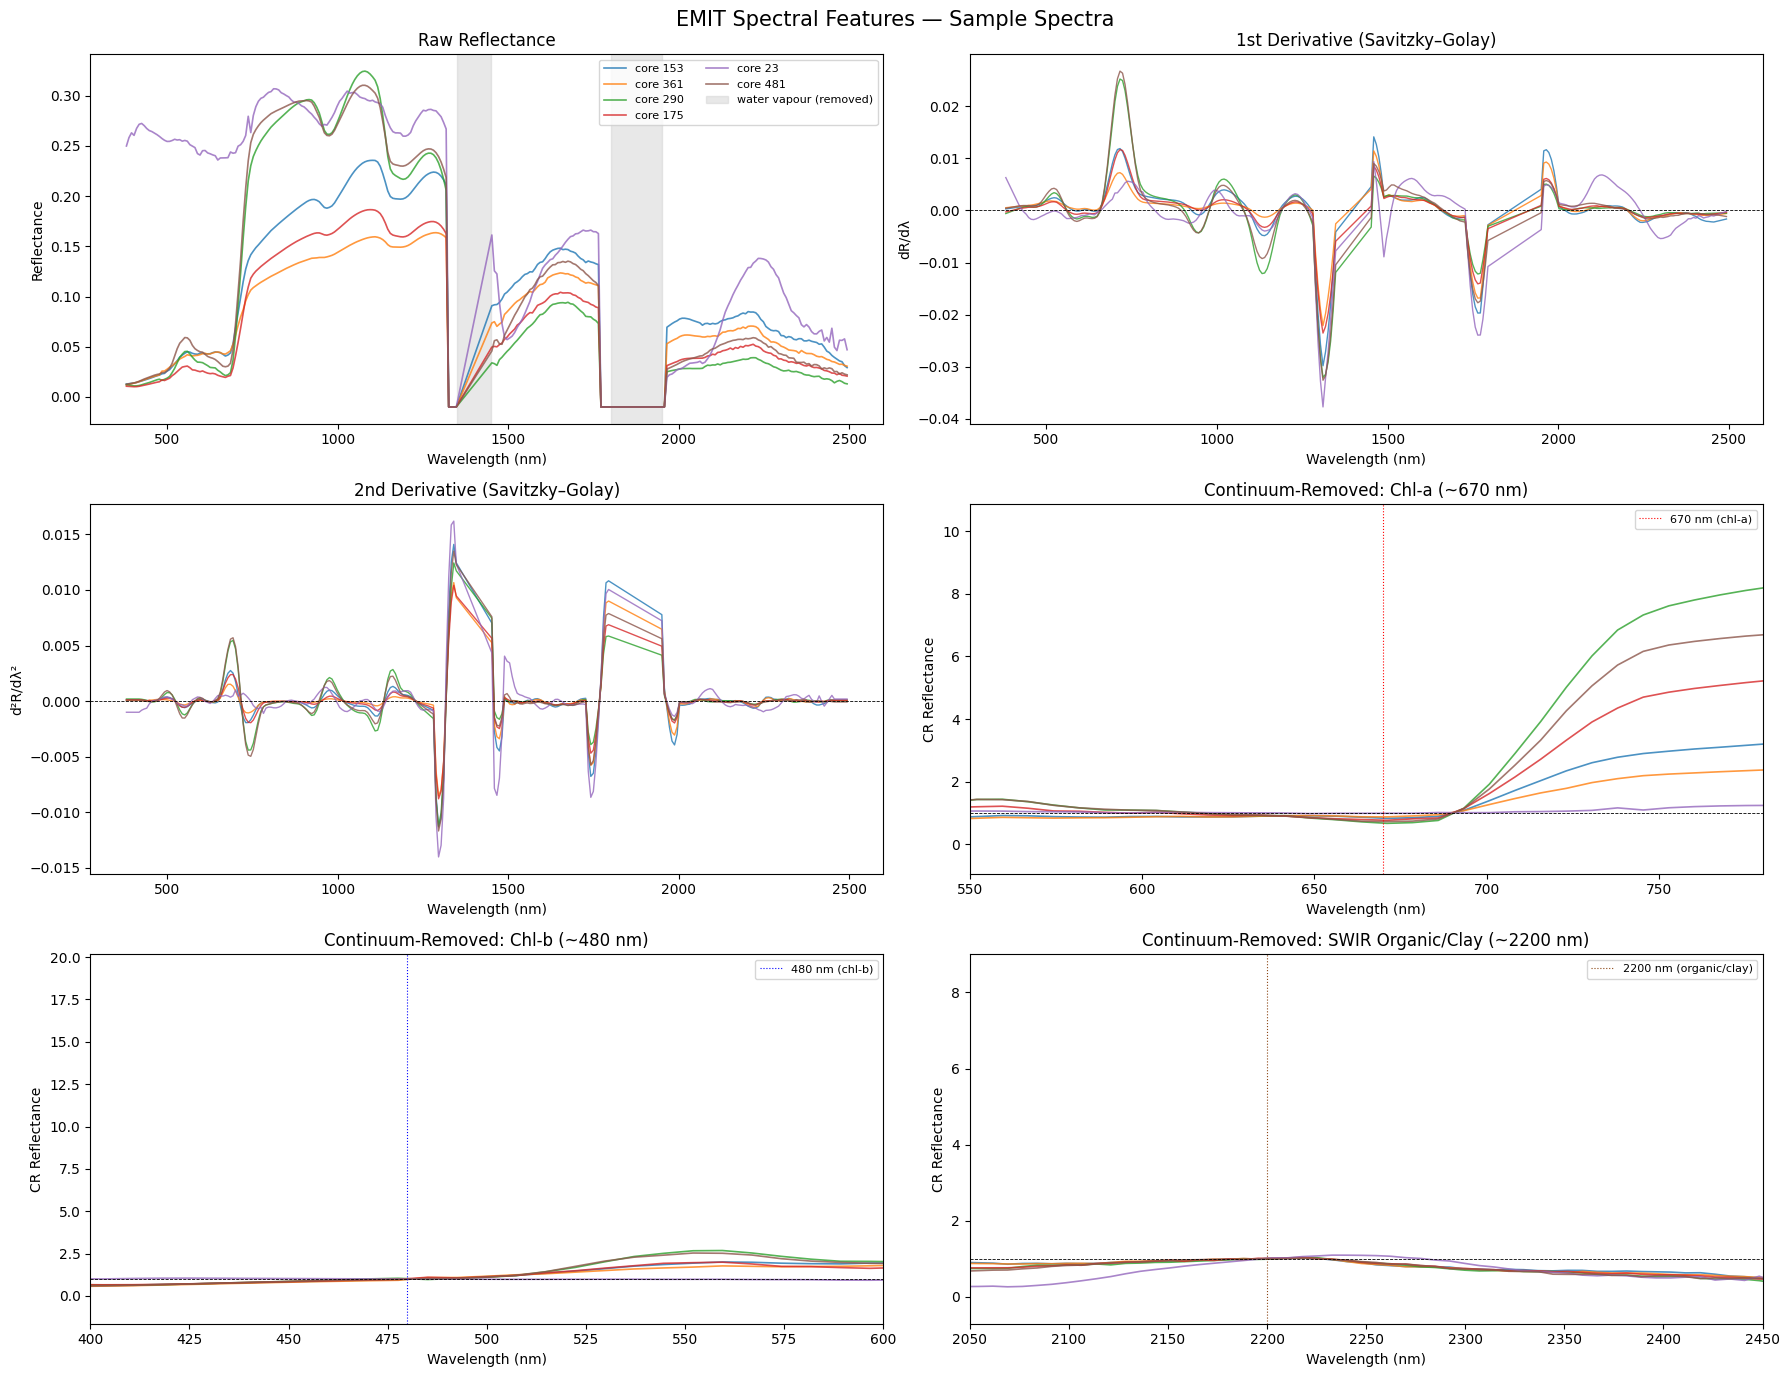

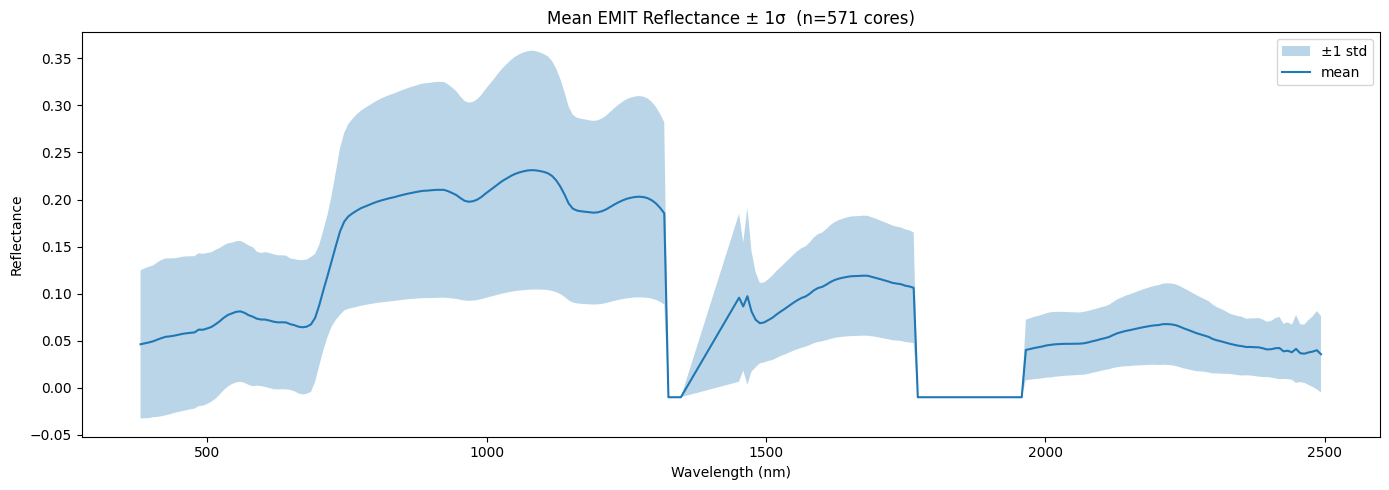

In [11]:
from scipy.signal import savgol_filter as _savgol
import numpy as np
import matplotlib.pyplot as plt

# ── sample a few representative spectra ──────────────────────────────────────
N_SAMPLES = 6
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(spectra_df), size=min(N_SAMPLES, len(spectra_df)), replace=False)
sample_spectra = spectra_df.iloc[sample_idx][keep_cols].fillna(0.0).values  # (N, B)

wl = wavelengths[keep_mask]  # wavelengths for kept bands
n_b = len(wl)

# ── derivatives ──────────────────────────────────────────────────────────────
win = min(11, n_b if n_b % 2 == 1 else n_b - 1)
deriv1 = _savgol(sample_spectra, window_length=win, polyorder=2, deriv=1, axis=1)
deriv2 = _savgol(sample_spectra, window_length=win, polyorder=2, deriv=2, axis=1)


# ── continuum removal at absorption bands ────────────────────────────────────
def remove_continuum(X, wavelengths, target_nm, half_window=3):
    """Divide each spectrum by its local continuum around target_nm."""
    idx = int(np.argmin(np.abs(wavelengths - target_nm)))
    left = max(0, idx - half_window)
    right = min(X.shape[1] - 1, idx + half_window)
    continuum = (X[:, left] + X[:, right]) / 2.0
    return X / np.where(continuum[:, None] > 0, continuum[:, None], 1e-8)


cr_chl_a = remove_continuum(sample_spectra, wl, 670)  # red chl-a
cr_chl_b = remove_continuum(sample_spectra, wl, 480)  # blue chl-b
cr_swir = remove_continuum(sample_spectra, wl, 2200)  # SWIR organic/clay

colors = [plt.cm.tab10(i) for i in range(N_SAMPLES)]

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle("EMIT Spectral Features — Sample Spectra", fontsize=15)

# 1. Raw reflectance
ax = axes[0, 0]
for i, spec in enumerate(sample_spectra):
    ax.plot(wl, spec, color=colors[i], alpha=0.8, linewidth=1.2, label=f"core {sample_idx[i]}")
ax.axvspan(1350, 1450, color="lightgray", alpha=0.5, label="water vapour (removed)")
ax.axvspan(1800, 1950, color="lightgray", alpha=0.5)
ax.set_title("Raw Reflectance")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.legend(fontsize=8, ncol=2)

# 2. 1st derivative
ax = axes[0, 1]
for i, d in enumerate(deriv1):
    ax.plot(wl, d, color=colors[i], alpha=0.8, linewidth=1.0)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("1st Derivative (Savitzky–Golay)")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("dR/dλ")

# 3. 2nd derivative
ax = axes[1, 0]
for i, d in enumerate(deriv2):
    ax.plot(wl, d, color=colors[i], alpha=0.8, linewidth=1.0)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("2nd Derivative (Savitzky–Golay)")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("d²R/dλ²")

# 4. Continuum-removed: chl-a ~670 nm
ax = axes[1, 1]
for i, spec in enumerate(cr_chl_a):
    ax.plot(wl, spec, color=colors[i], alpha=0.8, linewidth=1.2)
ax.axhline(1.0, color="black", linewidth=0.6, linestyle="--")
ax.axvline(670, color="red", linewidth=0.8, linestyle=":", label="670 nm (chl-a)")
ax.set_xlim(550, 780)
ax.set_title("Continuum-Removed: Chl-a (~670 nm)")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("CR Reflectance")
ax.legend(fontsize=8)

# 5. Continuum-removed: chl-b ~480 nm
ax = axes[2, 0]
for i, spec in enumerate(cr_chl_b):
    ax.plot(wl, spec, color=colors[i], alpha=0.8, linewidth=1.2)
ax.axhline(1.0, color="black", linewidth=0.6, linestyle="--")
ax.axvline(480, color="blue", linewidth=0.8, linestyle=":", label="480 nm (chl-b)")
ax.set_xlim(400, 600)
ax.set_title("Continuum-Removed: Chl-b (~480 nm)")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("CR Reflectance")
ax.legend(fontsize=8)

# 6. Continuum-removed: SWIR ~2200 nm
ax = axes[2, 1]
for i, spec in enumerate(cr_swir):
    ax.plot(wl, spec, color=colors[i], alpha=0.8, linewidth=1.2)
ax.axhline(1.0, color="black", linewidth=0.6, linestyle="--")
ax.axvline(2200, color="saddlebrown", linewidth=0.8, linestyle=":", label="2200 nm (organic/clay)")
ax.set_xlim(2050, 2450)
ax.set_title("Continuum-Removed: SWIR Organic/Clay (~2200 nm)")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("CR Reflectance")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── mean ± std envelope across all cores ─────────────────────────────────────
all_spectra = spectra_df[keep_cols].fillna(0.0).values
mean_spec = all_spectra.mean(axis=0)
std_spec = all_spectra.std(axis=0)

fig2, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(wl, mean_spec - std_spec, mean_spec + std_spec, alpha=0.3, label="±1 std")
ax.plot(wl, mean_spec, linewidth=1.5, label="mean")
ax.set_title(f"Mean EMIT Reflectance ± 1σ  (n={len(all_spectra):,} cores)")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
import requests
from io import BytesIO

# Band-to-wavelength mapping (285 bands, 381–2493 nm, step ≈ 7.44 nm/band):
#   Band 150 ≈ 1497 nm (SWIR)   Band 51 ≈ 760 nm (NIR)    Band 30 ≈ 604 nm (red-edge)
#   Band 35  ≈ 641 nm (red)     Band 23 ≈ 552 nm (green)  Band 11 ≈ 463 nm (blue)

# getThumbURL requires a serialized GeoJSON dict, not an ee.Geometry object
roi_geojson = ROI.getInfo()


def fetch_thumb(image, bands, vmin, vmax, dims=512):
    url = image.getThumbURL(
        {
            "bands": bands,
            "min": vmin,
            "max": vmax,
            "region": roi_geojson,
            "dimensions": dims,
            "format": "png",
        }
    )
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    return plt.imread(BytesIO(resp.content))


fc_img = fetch_thumb(
    emit_mosaic,
    ["reflectance_150", "reflectance_51", "reflectance_30"],  # SWIR / NIR / red-edge
    vmin=0,
    vmax=0.35,
)
tc_img = fetch_thumb(
    emit_mosaic,
    ["reflectance_35", "reflectance_23", "reflectance_11"],  # Red / Green / Blue
    vmin=0,
    vmax=0.25,
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(fc_img)
axes[0].axis("off")
axes[0].set_title(
    "False Color  (R=SWIR ~1497 nm · G=NIR ~760 nm · B=Red-edge ~604 nm)",
    fontsize=10,
)

axes[1].imshow(tc_img)
axes[1].axis("off")
axes[1].set_title(
    "True Color  (R=Red ~641 nm · G=Green ~552 nm · B=Blue ~463 nm)",
    fontsize=10,
)

fig.suptitle("EMIT L2A Mosaic — US Lower Coast Study Region", fontsize=13)
plt.tight_layout()
plt.show()

HTTPError: 400 Client Error: Bad Request for url: https://earthengine.googleapis.com/v1/projects/ee-klewtak/thumbnails/816c10e226a9daabc81e781797c510f4-f86ee8d2f10d48a94a31206b3f4a2f41:getPixels

## Modeling


In [13]:
from scipy.signal import savgol_filter
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore", category=UserWarning)


def compute_spectral_features(X_raw, wavelengths_kept):
    """Augment raw reflectance with first derivative and spectral indices. Returns (X_augmented, feature_names)."""
    n_samples, n_bands = X_raw.shape

    # Savitzky–Golay first derivative
    window = min(11, n_bands if n_bands % 2 == 1 else n_bands - 1)
    X_deriv = savgol_filter(X_raw, window_length=window, polyorder=2, deriv=1, axis=1)

    # Continuum-removed depth at key absorption regions
    # ~480nm (chlorophyll), ~670nm (chlorophyll-b), ~2200nm (clay/organic)
    indices = {}
    for target_nm, name in [(480, "blue_abs"), (670, "red_abs"), (2200, "swir_abs")]:
        idx = np.argmin(np.abs(wavelengths_kept - target_nm))
        left = max(0, idx - 3)
        right = min(n_bands - 1, idx + 3)
        continuum = (X_raw[:, left] + X_raw[:, right]) / 2.0
        depth = 1.0 - X_raw[:, idx] / np.where(continuum > 0, continuum, 1e-8)
        indices[name] = depth

    nir_idx = np.argmin(np.abs(wavelengths_kept - 850))
    red_idx = np.argmin(np.abs(wavelengths_kept - 670))
    nir = X_raw[:, nir_idx]
    red = X_raw[:, red_idx]
    indices["ndvi"] = (nir - red) / np.where((nir + red) > 0, nir + red, 1e-8)

    # mean reflectance in SWIR
    swir_mask = (wavelengths_kept >= 2000) & (wavelengths_kept <= 2400)
    if swir_mask.any():
        indices["swir_mean"] = X_raw[:, swir_mask].mean(axis=1)

    # spectral slope
    vis_mask = (wavelengths_kept >= 450) & (wavelengths_kept <= 700)
    if vis_mask.any() and swir_mask.any():
        indices["vis_swir_slope"] = X_raw[:, swir_mask].mean(axis=1) - X_raw[:, vis_mask].mean(axis=1)

    index_array = np.column_stack(list(indices.values()))
    X_aug = np.hstack([X_raw, X_deriv, index_array])

    feature_names = [f"raw_{i}" for i in range(n_bands)] + [f"deriv_{i}" for i in range(n_bands)] + list(indices.keys())
    return X_aug, feature_names


class SpectralCNN(nn.Module):
    """CNN that treats the spectrum as a 1D signal."""

    def __init__(self, n_input: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(32, 64, kernel_size=5, padding=4, dilation=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),
            nn.Dropout(0.2),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(4),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.features(x)
        return self.regressor(x)


# RegressorMixin must come before BaseEstimator so that __sklearn_tags__ sets
# estimator_type = "regressor" (required by sklearn >= 1.6 is_regressor check).
class CNNRegressor(RegressorMixin, BaseEstimator):
    """Wraps SpectralCNN as a sklearn-compatible regressor."""

    def __init__(self, n_input=30, epochs=200, lr=1e-3, patience=25, batch_size=32):
        self.n_input = n_input
        self.epochs = epochs
        self.lr = lr
        self.patience = patience
        self.batch_size = batch_size

    def fit(self, X, y):
        self.scaler_ = StandardScaler()
        X = self.scaler_.fit_transform(X)
        X_t = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

        n_val = max(1, int(0.15 * len(X)))
        idx = np.random.RandomState(42).permutation(len(X))
        train_idx, val_idx = idx[n_val:], idx[:n_val]

        train_ds = TensorDataset(X_t[train_idx], y_t[train_idx])
        val_ds = TensorDataset(X_t[val_idx], y_t[val_idx])
        train_loader = DataLoader(train_ds, batch_size=self.batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=self.batch_size)

        self.model_ = SpectralCNN(self.n_input).to(DEVICE)
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr, weight_decay=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)
        criterion = nn.MSELoss()

        best_val, best_state, patience_ctr = float("inf"), None, 0
        for epoch in range(1, self.epochs + 1):
            self.model_.train()
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                criterion(self.model_(Xb), yb).backward()
                optimizer.step()

            self.model_.eval()
            val_loss = 0.0
            with torch.no_grad():
                for Xb, yb in val_loader:
                    Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                    val_loss += criterion(self.model_(Xb), yb).item() * len(Xb)
            val_loss /= len(val_ds)
            scheduler.step(val_loss)

            if val_loss < best_val:
                best_val = val_loss
                patience_ctr = 0
                best_state = {k: v.cpu().clone() for k, v in self.model_.state_dict().items()}
            else:
                patience_ctr += 1
            if patience_ctr >= self.patience:
                break

        if best_state:
            self.model_.load_state_dict(best_state)
        return self

    def predict(self, X):
        X = self.scaler_.transform(X)
        X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        self.model_.eval()
        with torch.no_grad():
            return self.model_(X_t).cpu().numpy().flatten()


def prepare_data(spectra_df, carbon_df, keep_cols, wavelengths_kept, n_pca=N_PCA_COMPONENTS, min_samples=MIN_SAMPLES):
    """Merge, engineer features, PCA-reduce, split. Returns dict or None if too few samples."""
    merged = spectra_df.merge(
        carbon_df[["study_id", "site_id", "core_id", "fraction_carbon"]],
        on=["study_id", "site_id", "core_id"],
    )

    X_raw = merged[keep_cols].copy()
    y = merged["fraction_carbon"].copy()

    valid = X_raw.notna().any(axis=1) & y.notna()
    X_raw = X_raw[valid].fillna(0.0).values
    y = y[valid].values

    if len(X_raw) < min_samples:
        return None

    # feature engineering
    X_aug, feat_names = compute_spectral_features(X_raw, wavelengths_kept)
    print(
        f"  Features: {X_raw.shape[1]} raw + {X_raw.shape[1]} deriv + "
        f"{X_aug.shape[1] - 2*X_raw.shape[1]} indices = {X_aug.shape[1]} total"
    )

    # split
    X_train, X_test, y_train, y_test = train_test_split(X_aug, y, test_size=0.2, random_state=42)

    # scale and pca
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    n_comp = min(n_pca, X_train_s.shape[0], X_train_s.shape[1])
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_s)
    X_test_pca = pca.transform(X_test_s)
    print(f"  PCA: {n_comp} components → {pca.explained_variance_ratio_.sum():.1%} variance")

    return {
        "X_train": X_train_pca,
        "X_test": X_test_pca,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
        "pca": pca,
        "feat_names": feat_names,
    }


def build_ensemble(n_input):
    """Build ensemble of regressors."""
    estimators = [
        ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 20))),
        (
            "rf",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=10,
                min_samples_leaf=5,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1,
            ),
        ),
        (
            "gbr",
            GradientBoostingRegressor(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                min_samples_leaf=5,
                random_state=42,
            ),
        ),
        ("cnn", CNNRegressor(n_input=n_input, epochs=200, patience=25)),
    ]

    stack = StackingRegressor(
        estimators=estimators,
        final_estimator=RidgeCV(alphas=np.logspace(-2, 2, 10)),
        cv=5,
        n_jobs=1,
    )
    return stack, estimators


print("Model infrastructure ready.")

Model infrastructure ready.


## Train and evaluate for each depth

In [14]:
wavelengths_kept = wavelengths[keep_mask]
results = {}

for depth in DEPTH_TARGETS:
    label = f"{depth}cm"
    print(f"\n{'='*60}")
    print(f"DEPTH TARGET: {depth} cm")
    print(f"{'='*60}")

    data = prepare_data(spectra_df, depth_datasets[depth], keep_cols, wavelengths_kept)
    if data is None:
        print(f"  Skipping {label}: too few samples (need >= {MIN_SAMPLES}).")
        continue

    X_train, X_test = data["X_train"], data["X_test"]
    y_train, y_test = data["y_train"], data["y_test"]
    n_input = X_train.shape[1]
    print(f"  Train: {len(X_train):,}  Test: {len(X_test):,}")

    # CV scores
    print(f"\nCross-validated base model scores:")
    cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

    base_models = {
        "Ridge": RidgeCV(alphas=np.logspace(-3, 3, 20)),
        "Random Forest": RandomForestRegressor(
            n_estimators=500,
            max_depth=10,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1,
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            min_samples_leaf=5,
            random_state=42,
        ),
    }

    cv_results = {}
    for name, model in base_models.items():
        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
            return_train_score=False,
            n_jobs=-1,
        )
        r2_mean = scores["test_r2"].mean()
        r2_std = scores["test_r2"].std()
        mae_mean = -scores["test_neg_mean_absolute_error"].mean()
        rmse_mean = -scores["test_neg_root_mean_squared_error"].mean()
        cv_results[name] = {"r2": r2_mean, "r2_std": r2_std, "mae": mae_mean, "rmse": rmse_mean}
        print(f"  {name:20s}: R²={r2_mean:.4f} ± {r2_std:.4f}  " f"MAE={mae_mean:.4f}  RMSE={rmse_mean:.4f}")

    # CNN
    print(f"{'1D-CNN':20s}: (training)")

    # fit ensemble on train
    print(f"\nFitting ensemble:")
    stack, _ = build_ensemble(n_input)
    stack.fit(X_train, y_train)

    # evaluation
    y_pred_stack = stack.predict(X_test)
    test_results = {
        "Ensemble (Stack)": {
            "y_pred": y_pred_stack,
            "r2": r2_score(y_test, y_pred_stack),
            "mae": mean_absolute_error(y_test, y_pred_stack),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred_stack)),
        }
    }

    # individual test predictions
    for name, estimator in stack.named_estimators_.items():
        y_pred_i = estimator.predict(X_test)
        test_results[name] = {
            "y_pred": y_pred_i,
            "r2": r2_score(y_test, y_pred_i),
            "mae": mean_absolute_error(y_test, y_pred_i),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred_i)),
        }

    print(f"\nTest set results:")
    for name, m in test_results.items():
        marker = "*" if name == "Ensemble (Stack)" else ""
        print(f"  {name:20s}: R²={m['r2']:.4f}  MAE={m['mae']:.4f}  RMSE={m['rmse']:.4f}{marker}")

    results[depth] = {
        "test_results": test_results,
        "cv_results": cv_results,
        "y_test": y_test,
        "stack": stack,
        "scaler": data["scaler"],
        "pca": data["pca"],
        "n_train": len(X_train),
        "n_test": len(X_test),
    }


DEPTH TARGET: 0 cm
  Features: 252 raw + 252 deriv + 6 indices = 510 total
  PCA: 30 components → 99.8% variance
  Train: 445  Test: 112

Cross-validated base model scores:
  Ridge               : R²=0.2459 ± 0.0520  MAE=0.0794  RMSE=0.0992
  Random Forest       : R²=0.3765 ± 0.0450  MAE=0.0705  RMSE=0.0904
  Gradient Boosting   : R²=0.3827 ± 0.0710  MAE=0.0656  RMSE=0.0897
1D-CNN              : (training)

Fitting ensemble:

Test set results:
  Ensemble (Stack)    : R²=0.5789  MAE=0.0543  RMSE=0.0711*
  ridge               : R²=0.3063  MAE=0.0742  RMSE=0.0912
  rf                  : R²=0.5009  MAE=0.0599  RMSE=0.0774
  gbr                 : R²=0.6150  MAE=0.0513  RMSE=0.0679
  cnn                 : R²=0.4417  MAE=0.0599  RMSE=0.0818

DEPTH TARGET: 30 cm
  Features: 252 raw + 252 deriv + 6 indices = 510 total
  PCA: 30 components → 99.9% variance
  Train: 122  Test: 31

Cross-validated base model scores:
  Ridge               : R²=-0.0549 ± 0.4756  MAE=0.0781  RMSE=0.1060
  Random For

## Depth Diagnostics

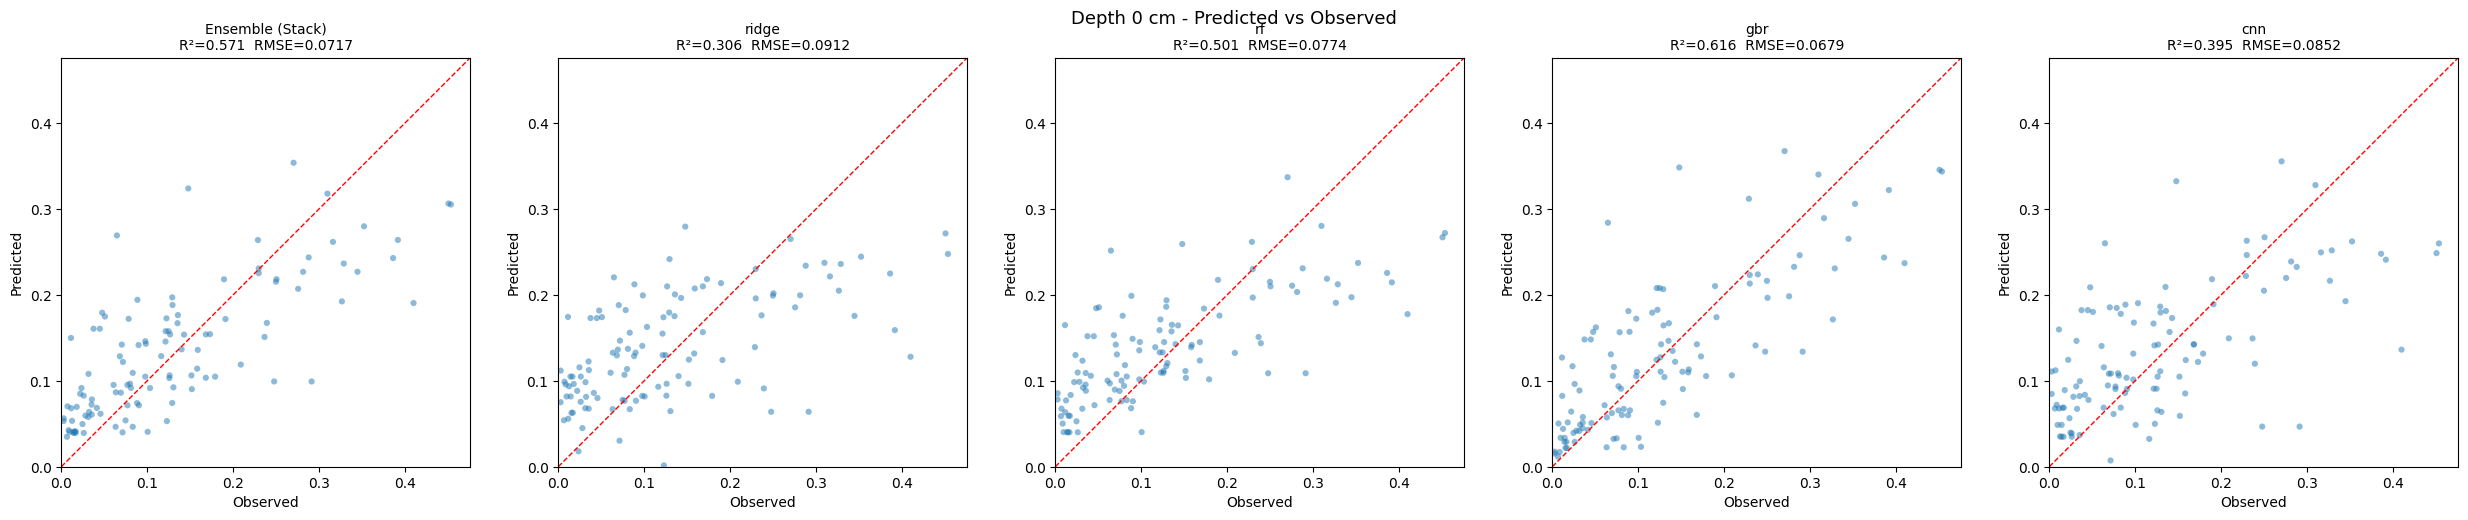

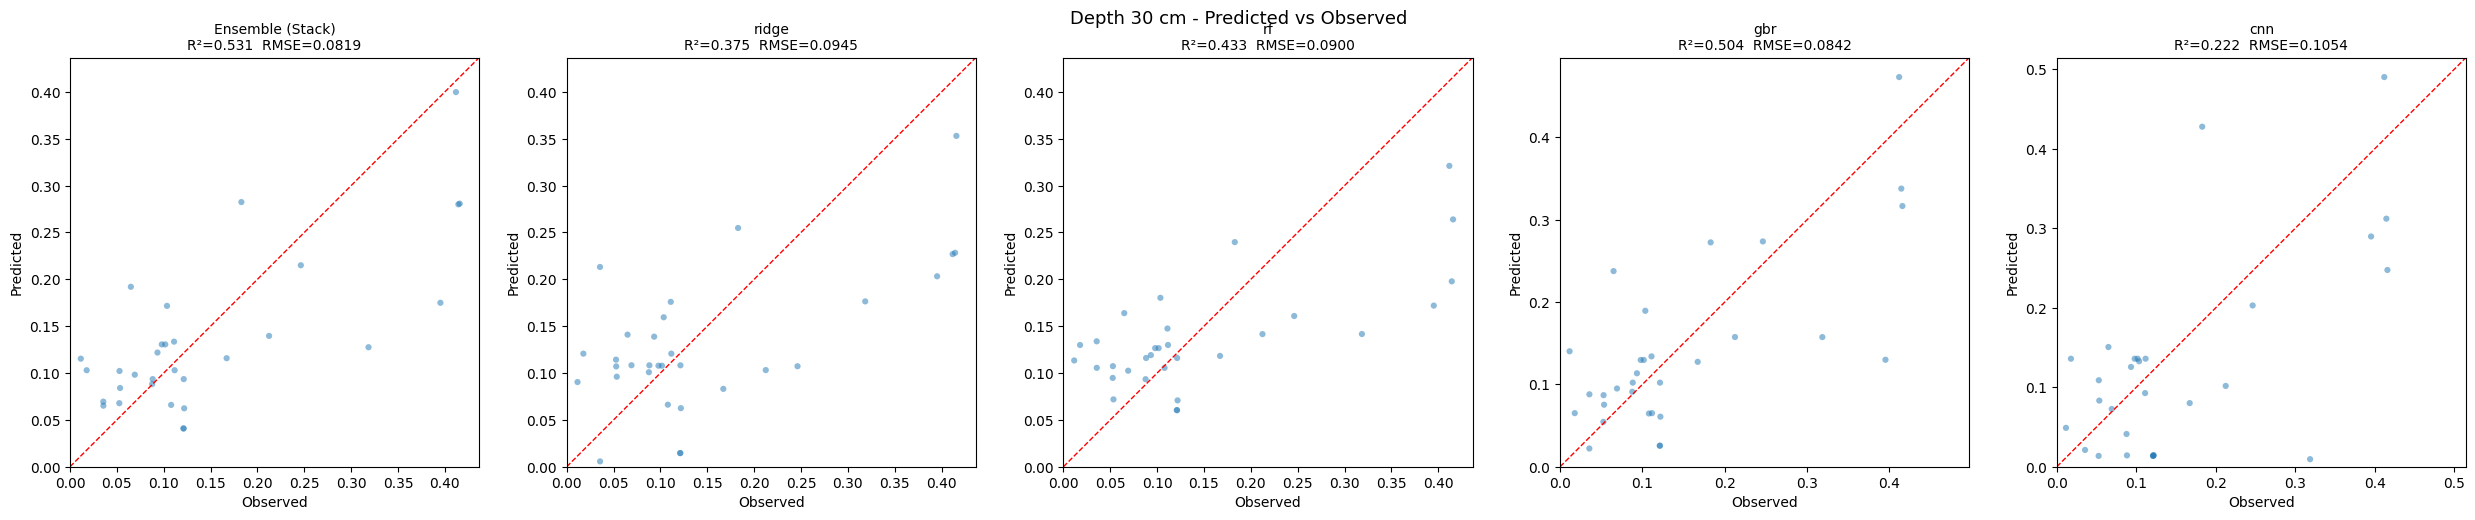

In [25]:
# predictions vs observations
for depth, res in results.items():
    test_res = res["test_results"]
    y_test = res["y_test"]
    n_models = len(test_res)

    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    for ax, (name, m) in zip(axes, test_res.items()):
        ax.scatter(y_test, m["y_pred"], alpha=0.5, s=20, edgecolors="none")
        lims = [0, max(y_test.max(), m["y_pred"].max()) * 1.05]
        ax.plot(lims, lims, "r--", linewidth=1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{name}\nR²={m['r2']:.3f}  RMSE={m['rmse']:.4f}", fontsize=10)
        ax.set_aspect("equal")

    fig.suptitle(f"Depth {depth} cm - Predicted vs Observed", fontsize=13)
    plt.tight_layout()
    plt.show()

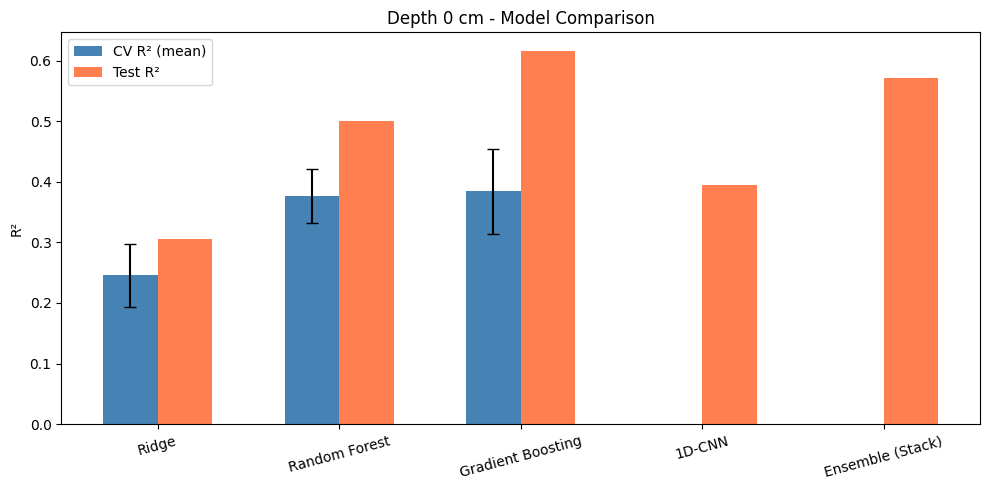

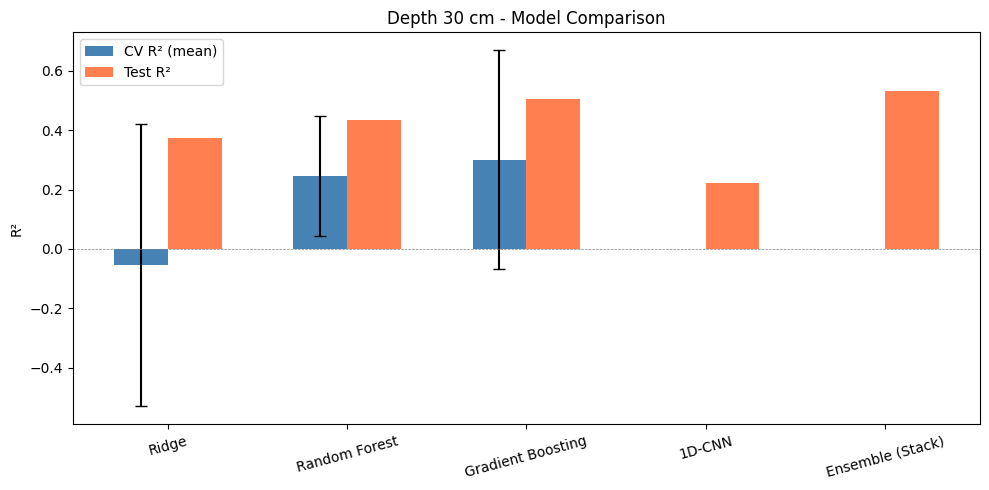

In [26]:
# r-squared comparison
for depth, res in results.items():
    cv_res = res["cv_results"]
    test_res = res["test_results"]

    model_names = list(cv_res.keys()) + ["1D-CNN", "Ensemble (Stack)"]
    cv_r2 = [cv_res[n]["r2"] for n in cv_res] + [np.nan, np.nan]
    cv_std = [cv_res[n]["r2_std"] for n in cv_res] + [0, 0]
    test_r2 = [test_res.get(n.lower().replace(" ", "_"), test_res.get(n, {})).get("r2", np.nan) for n in cv_res]
    # Map base model names to stacking estimator names
    name_map = {"Ridge": "ridge", "Random Forest": "rf", "Gradient Boosting": "gbr"}
    test_r2 = [test_res.get(name_map.get(n, n), {}).get("r2", np.nan) for n in cv_res]
    test_r2 += [test_res.get("cnn", {}).get("r2", np.nan), test_res["Ensemble (Stack)"]["r2"]]

    x = np.arange(len(model_names))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - 0.15, cv_r2, 0.3, label="CV R² (mean)", color="steelblue", yerr=cv_std, capsize=4)
    ax.bar(x + 0.15, test_r2, 0.3, label="Test R²", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15)
    ax.set_ylabel("R²")
    ax.set_title(f"Depth {depth} cm - Model Comparison")
    ax.legend()
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()

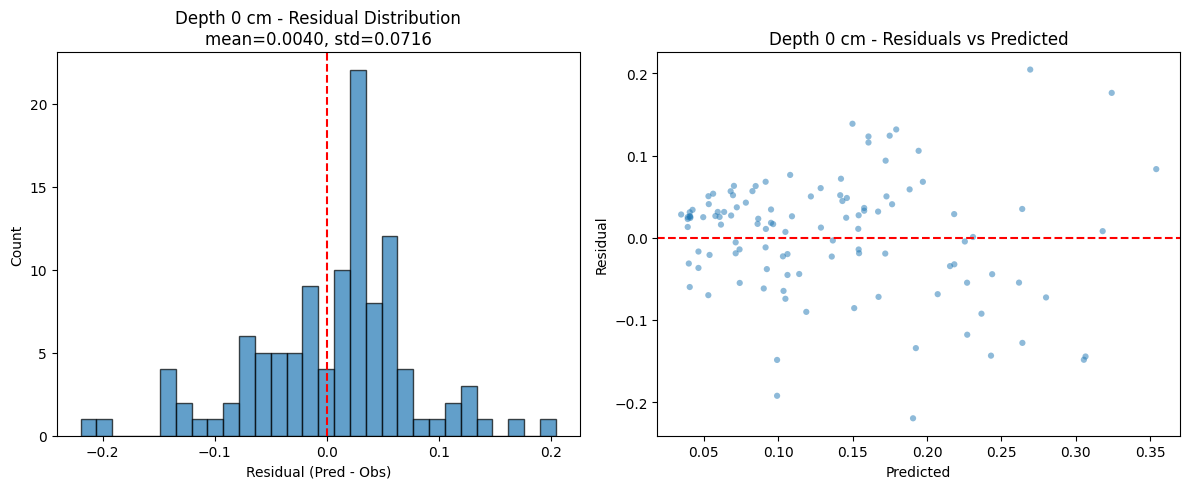

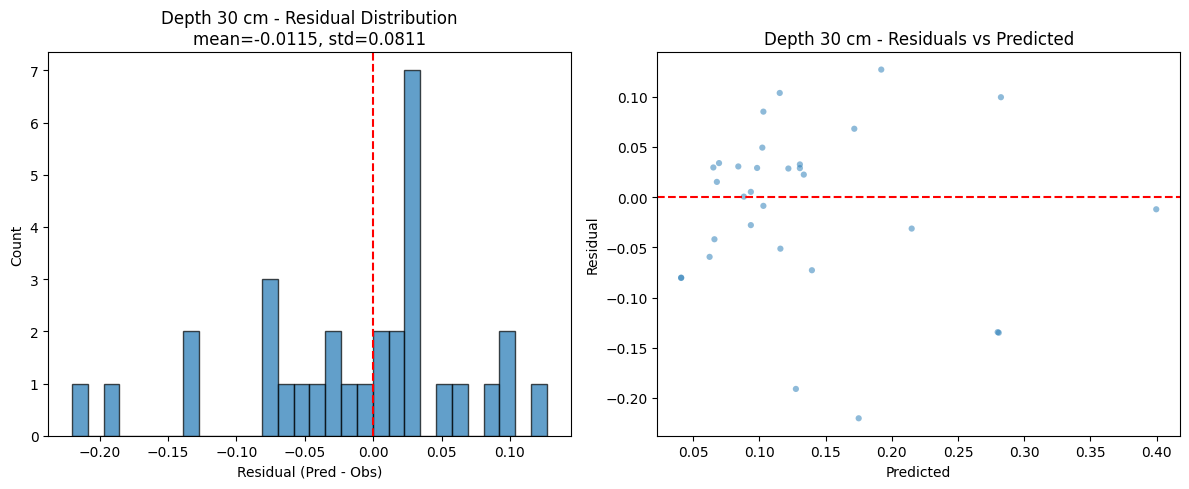

In [27]:
# residual distributions for ensemble
for depth, res in results.items():
    y_test = res["y_test"]
    y_pred = res["test_results"]["Ensemble (Stack)"]["y_pred"]
    residuals = y_pred - y_test

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.hist(residuals, bins=30, edgecolor="black", alpha=0.7)
    ax1.axvline(0, color="red", linestyle="--")
    ax1.set_xlabel("Residual (Pred - Obs)")
    ax1.set_ylabel("Count")
    ax1.set_title(
        f"Depth {depth} cm - Residual Distribution\n" f"mean={residuals.mean():.4f}, std={residuals.std():.4f}"
    )

    # residual vs predicted (for heteroscedasticity)
    ax2.scatter(y_pred, residuals, alpha=0.5, s=20, edgecolors="none")
    ax2.axhline(0, color="red", linestyle="--")
    ax2.set_xlabel("Predicted")
    ax2.set_ylabel("Residual")
    ax2.set_title(f"Depth {depth} cm - Residuals vs Predicted")

    plt.tight_layout()
    plt.show()

In [28]:
# summary table
summary_rows = []
for depth, res in results.items():
    ens = res["test_results"]["Ensemble (Stack)"]
    # Find best individual model
    best_name, best_r2 = "", -999
    for name, m in res["test_results"].items():
        if name != "Ensemble (Stack)" and m["r2"] > best_r2:
            best_name, best_r2 = name, m["r2"]

    summary_rows.append(
        {
            "Depth (cm)": depth,
            "N (train/test)": f"{res['n_train']}/{res['n_test']}",
            "Ensemble R²": round(ens["r2"], 4),
            "Ensemble MAE": round(ens["mae"], 4),
            "Ensemble RMSE": round(ens["rmse"], 4),
            "Best Base Model": best_name,
            "Best Base R²": round(best_r2, 4),
        }
    )

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

 Depth (cm) N (train/test)  Ensemble R²  Ensemble MAE  Ensemble RMSE Best Base Model  Best Base R²
          0        445/112       0.5715        0.0553         0.0717             gbr        0.6157
         30         122/31       0.5307        0.0625         0.0819             gbr        0.5038


## Modern Gradient Boosting + Optuna Hyperparameter Search

XGBoost, LightGBM, and CatBoost are tuned with Optuna's TPE sampler.  
Each study runs up to `N_TRIALS` trials or `OPTUNA_TIMEOUT` seconds, whichever comes first.  
Results are compared against the stacking ensemble from the previous section.

In [22]:
try:
    import optuna

    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    raise ImportError("uv add optuna")
try:
    import xgboost as xgb
except ImportError:
    raise ImportError("uv add xgboost")
try:
    import lightgbm as lgb
except ImportError:
    raise ImportError("uv add lightgbm")
try:
    from catboost import CatBoostRegressor

    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print("CatBoost not installed — skipping. `uv add catboost`")
try:
    from perpetual import PerpetualBooster

    HAS_PERPETUAL = True
except ImportError:
    HAS_PERPETUAL = False
    print("PerpetualBooster not installed — skipping. `uv add perpetual`")

# ── Tuning budget ─────────────────────────────────────────────────────────────
N_TRIALS = 60  # Optuna trials per model per depth
OPTUNA_TIMEOUT = 300  # seconds per model per depth (whichever limit hits first)

boosting_results = {}

for depth in DEPTH_TARGETS:
    if depth not in results:
        continue

    # Reconstruct PCA-reduced splits (deterministic — same seed=42 as main pipeline)
    data = prepare_data(spectra_df, depth_datasets[depth], keep_cols, wavelengths_kept)
    if data is None:
        continue

    X_tr, X_te = data["X_train"], data["X_test"]
    y_tr, y_te = data["y_train"], data["y_test"]

    print(f"\n{'='*60}")
    print(f"BOOSTING SWEEP — {depth} cm  (train={len(X_tr)}, test={len(X_te)})")
    print(f"{'='*60}")

    model_preds = {}

    # ── XGBoost ───────────────────────────────────────────────────────────────
    def _xgb_obj(trial, X_tr=X_tr, y_tr=y_tr, X_te=X_te, y_te=y_te):
        p = dict(
            n_estimators=trial.suggest_int("n_estimators", 300, 2000),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            learning_rate=trial.suggest_float("learning_rate", 5e-3, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
        )
        m = xgb.XGBRegressor(**p)
        m.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
        return r2_score(y_te, m.predict(X_te))

    study_xgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study_xgb.optimize(_xgb_obj, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT)

    best_xgb = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1, tree_method="hist")
    best_xgb.fit(X_tr, y_tr)
    yp_xgb = best_xgb.predict(X_te)
    model_preds["XGBoost"] = dict(
        y_pred=yp_xgb,
        r2=r2_score(y_te, yp_xgb),
        mae=mean_absolute_error(y_te, yp_xgb),
        rmse=np.sqrt(mean_squared_error(y_te, yp_xgb)),
        best_params=study_xgb.best_params,
    )
    print(
        f"  XGBoost:  R²={model_preds['XGBoost']['r2']:.4f}  "
        f"MAE={model_preds['XGBoost']['mae']:.4f}  "
        f"(best trial R²={study_xgb.best_value:.4f})"
    )

    # ── LightGBM ──────────────────────────────────────────────────────────────
    def _lgb_obj(trial, X_tr=X_tr, y_tr=y_tr, X_te=X_te, y_te=y_te):
        p = dict(
            n_estimators=trial.suggest_int("n_estimators", 300, 2000),
            num_leaves=trial.suggest_int("num_leaves", 20, 300),
            learning_rate=trial.suggest_float("learning_rate", 5e-3, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            min_child_samples=trial.suggest_int("min_child_samples", 5, 50),
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )
        m = lgb.LGBMRegressor(**p)
        m.fit(
            X_tr,
            y_tr,
            eval_set=[(X_te, y_te)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
        )
        return r2_score(y_te, m.predict(X_te))

    study_lgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study_lgb.optimize(_lgb_obj, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT)

    best_lgb = lgb.LGBMRegressor(**study_lgb.best_params, random_state=42, n_jobs=-1, verbose=-1)
    best_lgb.fit(X_tr, y_tr, callbacks=[lgb.log_evaluation(-1)])
    yp_lgb = best_lgb.predict(X_te)
    model_preds["LightGBM"] = dict(
        y_pred=yp_lgb,
        r2=r2_score(y_te, yp_lgb),
        mae=mean_absolute_error(y_te, yp_lgb),
        rmse=np.sqrt(mean_squared_error(y_te, yp_lgb)),
        best_params=study_lgb.best_params,
    )
    print(
        f"  LightGBM: R²={model_preds['LightGBM']['r2']:.4f}  "
        f"MAE={model_preds['LightGBM']['mae']:.4f}  "
        f"(best trial R²={study_lgb.best_value:.4f})"
    )

    # ── CatBoost ──────────────────────────────────────────────────────────────
    if HAS_CATBOOST:

        def _cat_obj(trial, X_tr=X_tr, y_tr=y_tr, X_te=X_te, y_te=y_te):
            p = dict(
                iterations=trial.suggest_int("iterations", 200, 1500),
                depth=trial.suggest_int("depth", 4, 10),
                learning_rate=trial.suggest_float("learning_rate", 5e-3, 0.3, log=True),
                l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
                bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.0),
                random_seed=42,
                verbose=0,
            )
            m = CatBoostRegressor(**p)
            m.fit(X_tr, y_tr, eval_set=(X_te, y_te), early_stopping_rounds=50, verbose=False)
            return r2_score(y_te, m.predict(X_te))

        study_cat = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
        study_cat.optimize(_cat_obj, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT)

        best_cat = CatBoostRegressor(**study_cat.best_params, random_seed=42, verbose=0)
        best_cat.fit(X_tr, y_tr, verbose=False)
        yp_cat = best_cat.predict(X_te)
        model_preds["CatBoost"] = dict(
            y_pred=yp_cat,
            r2=r2_score(y_te, yp_cat),
            mae=mean_absolute_error(y_te, yp_cat),
            rmse=np.sqrt(mean_squared_error(y_te, yp_cat)),
            best_params=study_cat.best_params,
        )
        print(
            f"  CatBoost: R²={model_preds['CatBoost']['r2']:.4f}  "
            f"MAE={model_preds['CatBoost']['mae']:.4f}  "
            f"(best trial R²={study_cat.best_value:.4f})"
        )

    # ── PerpetualBooster ──────────────────────────────────────────────────────
    # Valid constructor params (from perpetual.booster.PerpetualBooster.__init__):
    #   budget (float 0–1): primary complexity knob — higher = more trees/depth
    #   iteration_limit (int | None): hard cap on boosting rounds
    #   stopping_rounds (int): patience for early stopping
    #   max_bin (int): histogram bin count (controls granularity)
    #   seed (int)
    if HAS_PERPETUAL:

        def _perp_obj(trial, X_tr=X_tr, y_tr=y_tr, X_te=X_te, y_te=y_te):
            p = dict(
                budget=trial.suggest_float("budget", 0.1, 1.2),
                iteration_limit=trial.suggest_int("iteration_limit", 100, 2000),
                stopping_rounds=trial.suggest_int("stopping_rounds", 10, 100),
                max_bin=trial.suggest_int("max_bin", 64, 512),
                seed=42,
            )
            m = PerpetualBooster(objective="SquaredLoss", **p)
            m.fit(X_tr, y_tr)
            return r2_score(y_te, m.predict(X_te))

        study_perp = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
        study_perp.optimize(_perp_obj, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT)

        best_perp = PerpetualBooster(objective="SquaredLoss", **study_perp.best_params)
        best_perp.fit(X_tr, y_tr)
        yp_perp = best_perp.predict(X_te)
        model_preds["PerpetualBooster"] = dict(
            y_pred=yp_perp,
            r2=r2_score(y_te, yp_perp),
            mae=mean_absolute_error(y_te, yp_perp),
            rmse=np.sqrt(mean_squared_error(y_te, yp_perp)),
            best_params=study_perp.best_params,
        )
        print(
            f"  PerpetualBooster: R²={model_preds['PerpetualBooster']['r2']:.4f}  "
            f"MAE={model_preds['PerpetualBooster']['mae']:.4f}  "
            f"(best trial R²={study_perp.best_value:.4f})"
        )

    ens_r2 = results[depth]["test_results"]["Ensemble (Stack)"]["r2"]
    print(f"\n  (reference) Prior stacking ensemble: R²={ens_r2:.4f}")
    boosting_results[depth] = {"models": model_preds, "y_test": y_te}

print("\nDone.")

  Features: 252 raw + 252 deriv + 6 indices = 510 total
  PCA: 30 components → 99.8% variance

BOOSTING SWEEP — 0 cm  (train=445, test=112)
  XGBoost:  R²=0.6907  MAE=0.0462  (best trial R²=0.6907)
  LightGBM: R²=0.6686  MAE=0.0476  (best trial R²=0.6682)
  CatBoost: R²=0.6454  MAE=0.0482  (best trial R²=0.6505)
  PerpetualBooster: R²=0.6302  MAE=0.0516  (best trial R²=0.6302)

  (reference) Prior stacking ensemble: R²=0.5789
  Features: 252 raw + 252 deriv + 6 indices = 510 total
  PCA: 30 components → 99.9% variance

BOOSTING SWEEP — 30 cm  (train=122, test=31)
  XGBoost:  R²=0.6462  MAE=0.0583  (best trial R²=0.6462)
  LightGBM: R²=0.6598  MAE=0.0575  (best trial R²=0.6676)
  CatBoost: R²=0.5627  MAE=0.0623  (best trial R²=0.6083)
  PerpetualBooster: R²=0.5841  MAE=0.0595  (best trial R²=0.5841)

  (reference) Prior stacking ensemble: R²=0.5015

Done.


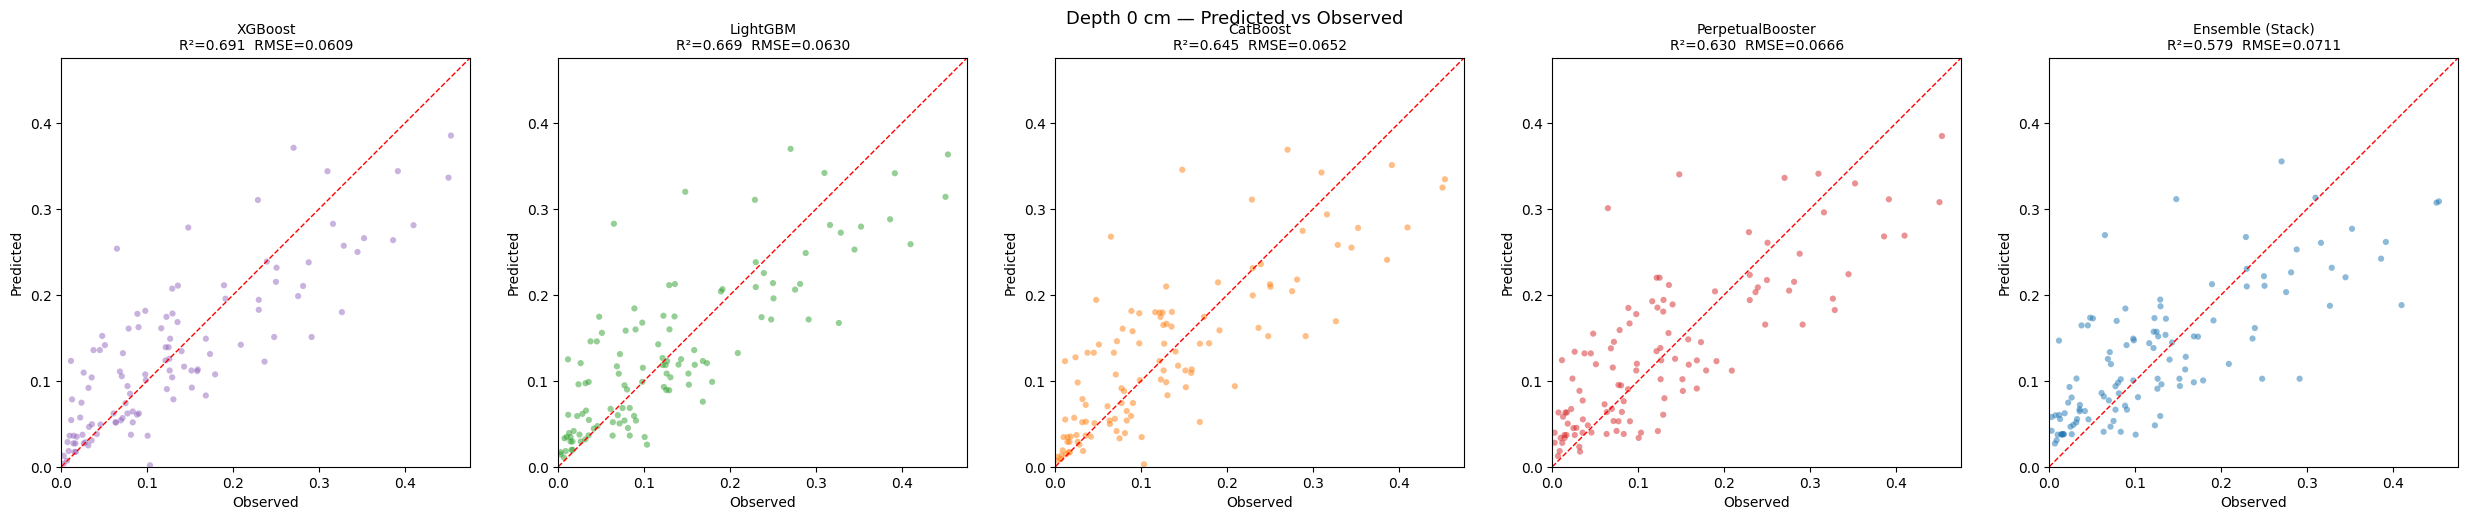

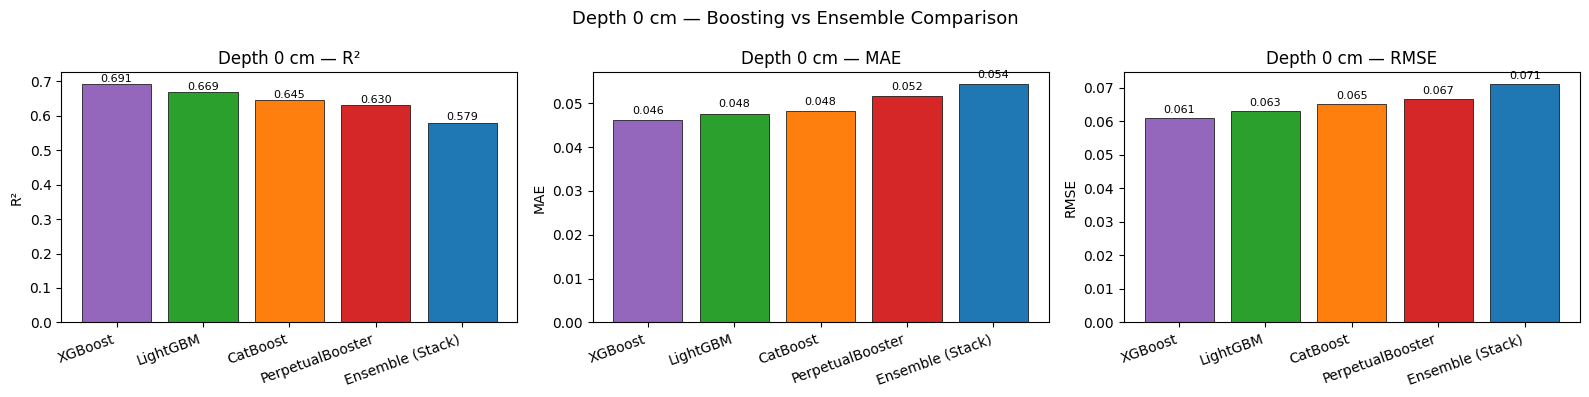


Best hyperparameters — depth 0 cm:
  XGBoost: {'n_estimators': 1746, 'max_depth': 4, 'learning_rate': 0.03878663963097709, 'subsample': 0.5999845798825145, 'colsample_bytree': 0.9884010899441952, 'min_child_weight': 4, 'reg_alpha': 1.393143192533616e-07, 'reg_lambda': 0.049376495896114155}
  LightGBM: {'n_estimators': 662, 'num_leaves': 202, 'learning_rate': 0.015146199824048955, 'subsample': 0.9747026700947788, 'colsample_bytree': 0.791608206823702, 'reg_alpha': 0.02380356035256528, 'reg_lambda': 3.785747414929348e-08, 'min_child_samples': 14}
  CatBoost: {'iterations': 402, 'depth': 4, 'learning_rate': 0.1734451662584154, 'l2_leaf_reg': 0.2537815508265665, 'bagging_temperature': 0.7080725777960455}
  PerpetualBooster: {'budget': 0.8827007560542209, 'iteration_limit': 1345, 'stopping_rounds': 57, 'max_bin': 102}


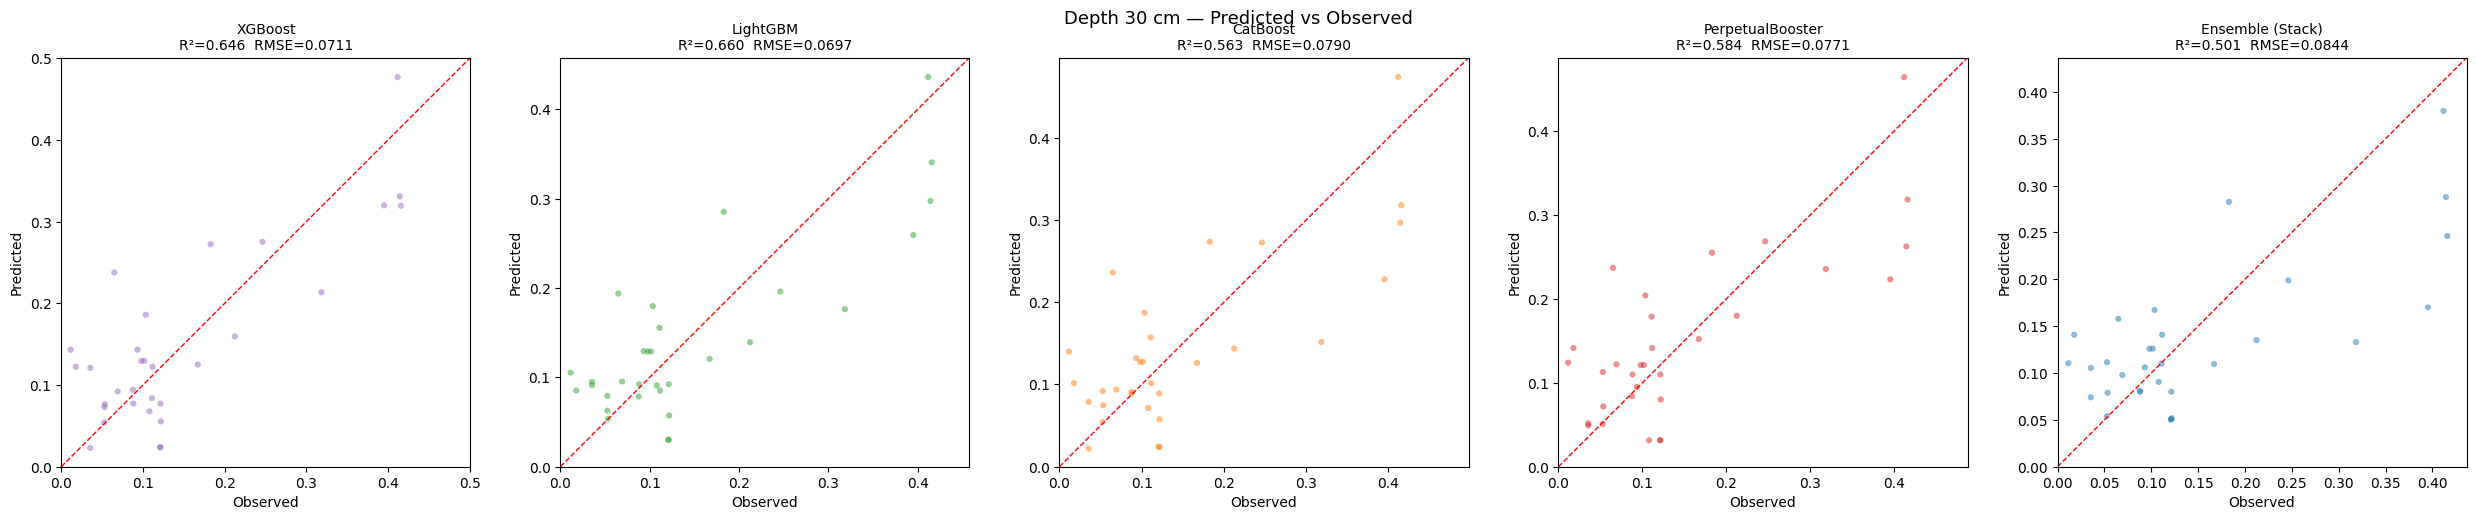

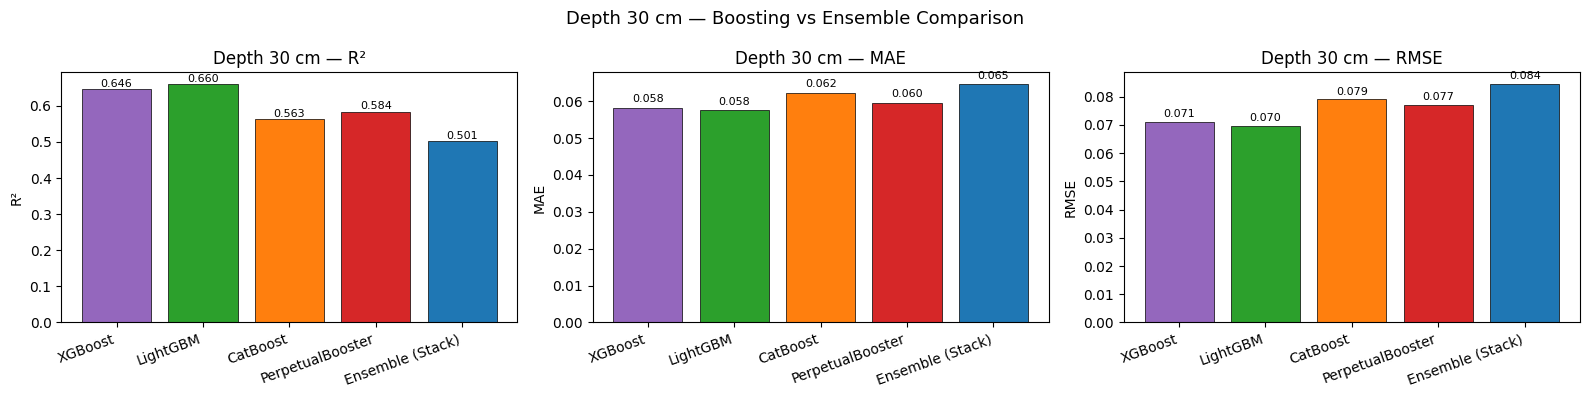


Best hyperparameters — depth 30 cm:
  XGBoost: {'n_estimators': 1659, 'max_depth': 4, 'learning_rate': 0.239713143707502, 'subsample': 0.6423666168789671, 'colsample_bytree': 0.732308769347828, 'min_child_weight': 3, 'reg_alpha': 0.22395150647879486, 'reg_lambda': 4.584944328587024e-05}
  LightGBM: {'n_estimators': 1325, 'num_leaves': 196, 'learning_rate': 0.0351795868282599, 'subsample': 0.7251069820328082, 'colsample_bytree': 0.9148655711983297, 'reg_alpha': 0.2765704642444973, 'reg_lambda': 3.4733641537761624e-07, 'min_child_samples': 9}
  CatBoost: {'iterations': 462, 'depth': 5, 'learning_rate': 0.02776477601728521, 'l2_leaf_reg': 0.0013965327379893554, 'bagging_temperature': 0.2626449382873869}
  PerpetualBooster: {'budget': 0.6666286446187886, 'iteration_limit': 622, 'stopping_rounds': 25, 'max_bin': 289}


In [23]:
# ── Side-by-side comparison: Optuna-tuned boosters vs stacking ensemble ───────
palette = {
    "XGBoost": "tab:purple",
    "LightGBM": "tab:green",
    "CatBoost": "tab:orange",
    "PerpetualBooster": "tab:red",
    "Ensemble (Stack)": "tab:blue",
}

for depth, br in boosting_results.items():
    y_te = br["y_test"]
    model_map = br["models"]

    # Add prior ensemble for comparison
    ens = results[depth]["test_results"]["Ensemble (Stack)"]
    all_models = {**model_map, "Ensemble (Stack)": ens}
    n_models = len(all_models)

    # ── Predicted vs Observed ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    for ax, (name, m) in zip(axes, all_models.items()):
        color = palette.get(name, "gray")
        ax.scatter(y_te, m["y_pred"], alpha=0.5, s=20, edgecolors="none", color=color)
        lim_max = max(y_te.max(), m["y_pred"].max()) * 1.05
        ax.plot([0, lim_max], [0, lim_max], "r--", linewidth=1)
        ax.set_xlim(0, lim_max)
        ax.set_ylim(0, lim_max)
        ax.set_aspect("equal")
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{name}\nR²={m['r2']:.3f}  RMSE={m['rmse']:.4f}", fontsize=10)

    fig.suptitle(f"Depth {depth} cm — Predicted vs Observed", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── R² comparison bar chart ────────────────────────────────────────────────
    names = list(all_models.keys())
    r2s = [all_models[n]["r2"] for n in names]
    maes = [all_models[n]["mae"] for n in names]
    rmses = [all_models[n]["rmse"] for n in names]
    colors = [palette.get(n, "gray") for n in names]

    x = np.arange(len(names))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, vals, ylabel in zip(axes, [r2s, maes, rmses], ["R²", "MAE", "RMSE"]):
        bars = ax.bar(x, vals, color=colors, edgecolor="black", linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=20, ha="right")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Depth {depth} cm — {ylabel}")
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
        if ylabel == "R²":
            ax.axhline(0, color="gray", linestyle="--", linewidth=0.6)

    fig.suptitle(f"Depth {depth} cm — Boosting vs Ensemble Comparison", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Best hyperparameters ───────────────────────────────────────────────────
    print(f"\nBest hyperparameters — depth {depth} cm:")
    for name, m in model_map.items():
        print(f"  {name}: {m['best_params']}")

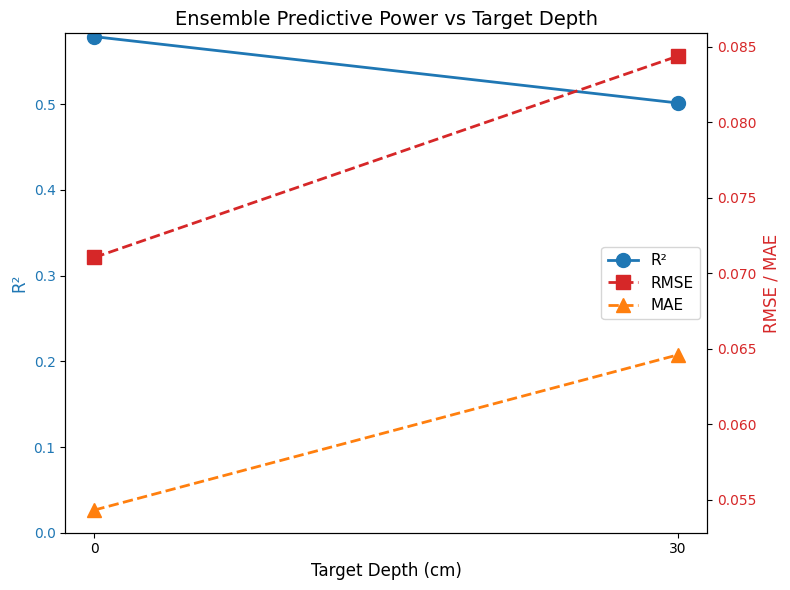

In [17]:
# ensemble R-squared and RMSE vs depth
depths = [d for d in results]
r2_vals = [results[d]["test_results"]["Ensemble (Stack)"]["r2"] for d in depths]
rmse_vals = [results[d]["test_results"]["Ensemble (Stack)"]["rmse"] for d in depths]
mae_vals = [results[d]["test_results"]["Ensemble (Stack)"]["mae"] for d in depths]

fig, ax1 = plt.subplots(figsize=(8, 6))

color_r2 = "tab:blue"
ax1.set_xlabel("Target Depth (cm)", fontsize=12)
ax1.set_ylabel("R²", color=color_r2, fontsize=12)
ax1.plot(depths, r2_vals, "o-", color=color_r2, linewidth=2, markersize=10, label="R²")
ax1.tick_params(axis="y", labelcolor=color_r2)
ax1.set_ylim(bottom=min(0, min(r2_vals) - 0.05))

ax2 = ax1.twinx()
color_rmse = "tab:red"
ax2.set_ylabel("RMSE / MAE", color=color_rmse, fontsize=12)
ax2.plot(depths, rmse_vals, "s--", color=color_rmse, linewidth=2, markersize=10, label="RMSE")
ax2.plot(depths, mae_vals, "^--", color="tab:orange", linewidth=2, markersize=10, label="MAE")
ax2.tick_params(axis="y", labelcolor=color_rmse)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=11)

ax1.set_xticks(depths)
ax1.set_title("Ensemble Predictive Power vs Target Depth", fontsize=14)
fig.tight_layout()
plt.show()

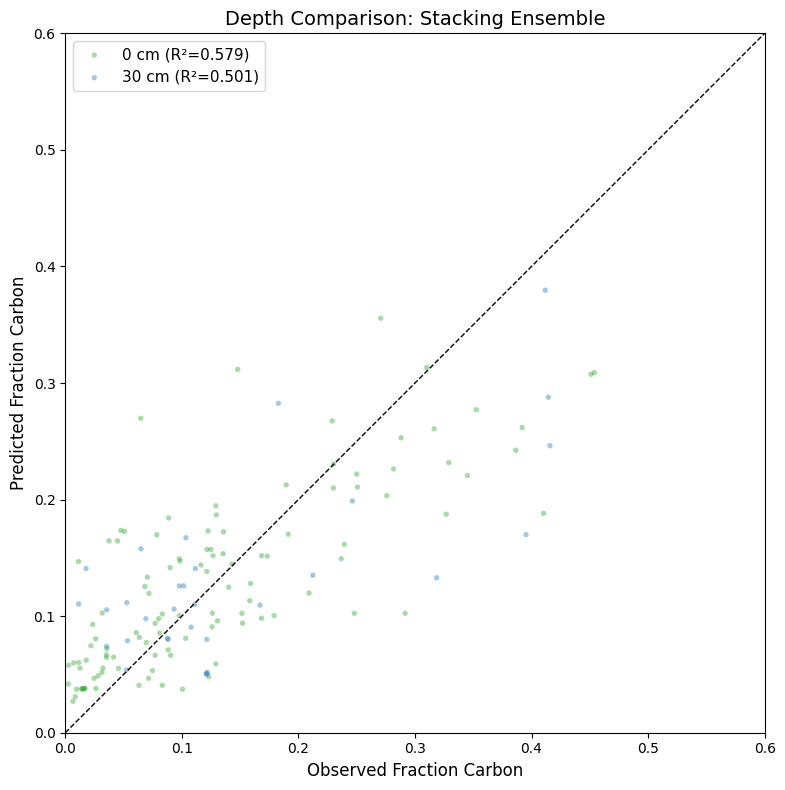

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))

colors = {0: "tab:green", 30: "tab:blue", 100: "tab:red"}
for depth, res in results.items():
    ens = res["test_results"]["Ensemble (Stack)"]
    ax.scatter(
        res["y_test"],
        ens["y_pred"],
        alpha=0.4,
        s=15,
        edgecolors="none",
        color=colors.get(depth, "gray"),
        label=f"{depth} cm (R²={ens['r2']:.3f})",
    )

lims = [0, 0.6]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Observed Fraction Carbon", fontsize=12)
ax.set_ylabel("Predicted Fraction Carbon", fontsize=12)
ax.set_title("Depth Comparison: Stacking Ensemble", fontsize=14)
ax.set_aspect("equal")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Save artifacts

In [31]:
import joblib

for depth, res in results.items():
    label = f"{depth}cm"
    # save full stacking ensemble
    joblib.dump(res["stack"], OUT_DIR / f"stack_ensemble_{label}.pkl")
    # scaler + PCA
    joblib.dump(res["scaler"], OUT_DIR / f"scaler_{label}.pkl")
    joblib.dump(res["pca"], OUT_DIR / f"pca_{label}.pkl")
    # test predictions
    ens = res["test_results"]["Ensemble (Stack)"]
    pd.DataFrame(
        {
            "observed": res["y_test"],
            "predicted": ens["y_pred"],
        }
    ).to_csv(OUT_DIR / f"test_predictions_{label}.csv", index=False)

# band metadata
pd.DataFrame(
    {
        "band_name": keep_cols,
        "wavelength_nm": wavelengths_kept,
    }
).to_csv(OUT_DIR / "band_metadata.csv", index=False)

# summary table
summary_df.to_csv(OUT_DIR / "depth_comparison_summary.csv", index=False)

print("Saved ensembles, scalers, PCA, predictions, and comparison summary.")

Saved ensembles, scalers, PCA, predictions, and comparison summary.
